In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from typing import List, Optional, TypedDict, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Load environmental variables from .env
load_dotenv()

True

In [2]:
llm = init_chat_model("gpt-4o-mini")


## **Define state and create a graph**

In [3]:
def coalesce(old: Optional[str], new: Optional[str]) -> Optional[str]:
    return new or old

class GState(BaseModel):
    messages: Annotated[list[AnyMessage], operator.add]
    city: Annotated[Optional[str], coalesce] = Field(default=None)
    interests: Annotated[List[str], operator.add] =  Field(description="Short list of interests - 3-5 elements")
    activities: Annotated[List[str], operator.add] = Field(description="List of activities.")
    sights: Annotated[List[str], operator.add] = Field(description="List of interesting places")

graph = StateGraph(GState)



##**Edges**

In [4]:

def collect_preferences(state: GState) -> dict:

    class RespStructure(BaseModel):
        city: str
        interests: Optional[List[str]]

    text = state.messages[-1].content if state.messages else ""
    prompt = f"""
From the user input:
<user_input>
{text}
</user_input>

extract information about the city name and user's interests. Both city and user interests can be empty.
"""
    ai = llm.with_structured_output(RespStructure).invoke(prompt)
    res = {
        "city": ai.city,
        "interests":  ai.interests if ai.interests else []
        }

    return res

def ask_activities(state: GState) -> dict:
    prompt = f"User likes {', '.join(state.interests)}. User will visit: {state.city}. Suggest 3 activities."
    out = llm.invoke(prompt).content.split("\n")
    return {"activities": [x for x in out if x.strip()]}


def ask_sights(state: GState) -> dict:
    prompt = f"Most interesting places to visit in {state.city}: 3 propositions."
    out = llm.invoke(prompt).content.split("\n")
    return {"sights": [x for x in out if x.strip()]}

def ask_both(state: GState) -> GState:
    return state

def ask_for_more(state: GState) -> GState:
    """Fallback node when we don't know city nor interests."""
    msg = AIMessage("Could you tell me which city you're visiting and what you like to do?")
    return state.model_copy(update={"messages": state.messages + [msg]})

def compose_answer(state: GState) -> GState:
    answer = (
        f"### City: {state.city}\n"
        f"### Interests (carry over if city changes): {', '.join(state.interests)}\n"
        f"### Activities:\n- " + "\n- ".join(state.activities) + "\n"
        f"### Locations:\n- " + "\n- ".join(state.sights)
    )
    state.messages = state.messages + [AIMessage(answer)]
    return state



In [5]:
def routing_decision(state: GState) -> str:
    """
    Decide where to go after classification.
    - both city and interests -> go to BOTH 'ask_activities' and 'ask_sights'
      (we will add separate conditional edges for that)
    - only city -> go to 'recommend_sights'
    - only interests -> go to 'recommend_activities'
    - none -> go to 'ask_for_more'
    """
    has_city = state.city is not None and state.city.strip() != ""
    has_interests = len(state.interests) > 0

    if has_city and has_interests:
        return "both"
    elif has_city:
        return "sights"
    elif has_interests:
        return "activities"
    else:
        return "ask"

##Create graph layout

In [6]:
graph.add_node("collect_preferences", collect_preferences)
graph.add_node("ask_activities", ask_activities)
graph.add_node("ask_sights", ask_sights)
graph.add_node("ask_both", ask_both)
graph.add_node("ask_for_more", ask_for_more)
graph.add_node("compose_answer", compose_answer)


graph.set_entry_point("collect_preferences")
graph.add_conditional_edges(
    "collect_preferences",
    routing_decision,
    {
        "both": "ask_both", #["ask_activities", "ask_sights"],  # fan-out
        "sights": "ask_sights",
        "activities": "ask_activities",
        "ask": "ask_for_more",
    },
)
graph.add_edge("ask_both", "ask_activities")
graph.add_edge("ask_both", "ask_sights")
graph.add_edge("ask_activities", "compose_answer")
graph.add_edge("ask_sights", "compose_answer")
graph.add_edge("compose_answer", END)

app = graph.compile()




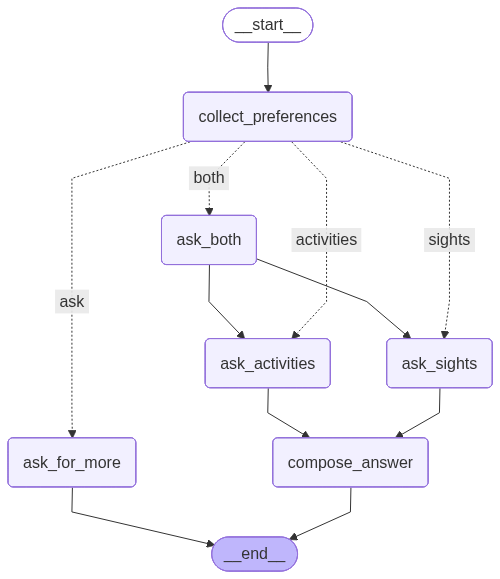

In [7]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [8]:
initial = GState(
    messages = [HumanMessage("I like street food and wine tasting. I will travel to Florence.")],
    city = "",
    interests = [],
    activities = [],
    sights = []
)
final_result1 = app.invoke(initial)
print(final_result1["messages"][-1].content)

### City: Florence
### Interests (carry over if city changes): street food, wine tasting, street food, wine tasting
### Activities:
- Absolutely! Here are three activities in Florence that combine your love for street food and wine tasting:
- 1. **Florence Street Food Tour**: Join a guided street food tour where you'll explore the local markets and neighborhoods. You'll get to taste a variety of traditional Tuscan street foods, like **Lampredotto** (a local tripe sandwich), **schiacciata** (a Tuscan flatbread), and various artisanal gelatos. A guide will share insights about the food culture and history of Florence.
- 2. **Wine Tasting Experience**: Book a wine tasting session at a local enoteca (wine bar) or wine shop. Here, you can sample some of the best Chiantis and other regional wines. Look for tastings that pair wines with local cheeses and cured meats to enhance your experience. Some places even offer educational sessions about the wines of Tuscany.
- 3. **Cooking Class with Wi

In [9]:
final_result2 = app.invoke(
    {"messages": [HumanMessage("Now I'm going to visit")]}
)
print(final_result2["messages"][-1].content)

Could you tell me which city you're visiting and what you like to do?
